# Pipeline stage 2: characterization of the predicted phage-encoded acetyltransferases

### Stage 2.1: overview of the predicted acetyltransferases

**Goals:**
* Link all predicted acetyltransferase cluster representatives to structure predictions.
* Manually inspect predicted structures of predicted acetyltransferases.
* Create final, deduplicated overview of the predicted acetyltransferase dataset.
* Classify the predicted acetyltransferases based on their structure. 
* Describe the predicted acetyltransferase protein dataset.

**Requires:**
* input_search.tsv stored in a_input/protein_overview/ : a tab-seperated aggregated overview of the NCBI proteins that are unannotated and within the expected size range of acetyltransferases for all phages (one NCBI protein entry per line).
* assessed_annotated_acetyltransferases.tsv stored in 1_search/b_assess_annotated/ : a tab-seperated overview of the NCBI and UniProt proteins of our phages that (i) contain 'GNAT' or 'acetyltransferase' in their protein name and (ii) have a structure that matches to proteins annotated as 'acetyltransferase' in either the PDB or the AlphaFold database, with each row representing one unique phage-protein pair.
* all_unknown_clustered.tsv stored in 1_search/c_assess_unknown/proteins_cluster/ : tab-seperated output of the MMseqs2 sequence-based clustering of the proteins of unknown function with the annotated acetyltransferases. Column 1 describes the cluster representatives, column 2 the cluster members.
* assessed_unknown.tsv stored in 1_search/c_assess_unknown/ : a tab-seperated overview of the NCBI proteins of our phages that (i) that are unannotated and within the expected size range of acetyltransferases and (ii) belong to a protein cluster that has a predicted structure that matches to proteins annotated as 'acetyltransferase' and/or 'GNAT' in at least 50% of either the PDB or the AlphaFold database FoldSeek hits, with each row representing one unique phage-protein pair.
* structure prediction results of representative proteins that are predicted acetyltransferases, stored in 1_search/b_assess_annotated/structure_prediction/results/YYYY/YYYY_relaxed.pdb or 1_search/c_assess_unknown/structure_prediction/results/YYYY/YYYY_relaxed.pdb (for predicted acetyltransferase protein YYYY) : relaxed best AlphaFold predicted structure

**Generates:**
* manual_assessment.tsv : tab-seperated file detailing the manual assessment of predicted acetyltransferases (as likely/possible/unlikely - column final_assessment) based on the visual presence of the GNAT characteristics (columns GNATlike, Vcleft, Bhelix, Ploop) for the clusters (column cluster_assessed) considered as predicted acetyltransferases (following either the annotated acetyltransferase or protein of unknown function identification pipeline - column identified_through), on the basis of the protein structure of the protein detailed in column protein_assessed (as described in goal 1). 
* predicted_acetyltransferase_overview.tsv : a tab-seperated overview of the final selection of proteins of our phages that are predicted to be acetyltranferases. Each row represents one unique phage-acetyltransferase pair, summarizing the protein through its sequence (column sequence), size (column length), identifiers (columns ncbi_protein_uid and duplicate_ncbi_protein_uid for NCBI identifiers and uniprot_protein_id for UniProt identifier), and protein names as obtained in this study (columns ncbi_protein_name and duplicate_ncbi_protein_name for NCBI names and uniprot_protein_name for UniProt names), with a True/False tag indicating whether the protein sequence was elongated (column elongated - see notebook Code_search_assess_annotated.ipynb for more details). In addition, we store how the protein was identified in this study as a predicted acetyltransferase (column identification_method), which similar protein was modeled and inspected (column sequence_cluster_ref_model), and which sequence/structure-based cluster it belongs to (column sequence_cluster_rep, structure_cluster_rep). Related to the phage, we store the virus name, taxonomic identifier and taxonomic lineage (columns virus_name, virus_taxid, name_taxid, virus_lineage), as well as the host name & host lineage (columns host_name, host_lineage).
* in folder structure_clustering:
    * in folder input_structures:
        * ncbi_uid_PROTEIN_relaxed.pdb: the (relaxed, if available) best AlphaFold prediction for every PROTEIN in the final predicted acetyltransferase dataset, copied from 1_search/b_assess_annotated/structure_prediction/results/ncbi_uid_PROTEIN/ncbi_uid_PROTEIN_relaxed.pdb or 1_search/c_assess_unknown/structure_prediction/results/ncbi_uid_PROTEIN/ncbi_uid_PROTEIN_relaxed.pdb
    * foldseek_cluster_act.slurm : jobscript to run FoldSeek clustering on the HPC
    * act_structure_clustered_all_seqs.fasta : FoldSeek output multifasta file containing all protein sequences, organised per structure cluster
    * act_structure_clustered_rep_seq.fasta : FoldSeek output multifasta file containing protein sequences of selected cluster representatives
    * act_structure_clustered_cluster.tsv : tab-seperated output of FoldSeek clustering. Column 1 describes the cluster representatives, column 2 the cluster members.
    * slurm-XXXX.out : output files for FoldSeek job

#### General settings, imports, variables and environments

Conda environment: viral_act_overview

Created with `conda create -n viral_act_overview python=3.10`. Then installed `jupyter notebook`, `pandas` through conda (command `conda install`), `seaborn`, `scipy` through pip (command below).

In [ ]:
!pip install seaborn

In [ ]:
!pip install scipy

In [1]:
!conda list --explicit

# This file may be used to create an environment using:
# $ conda create --name <env> --file <this file>
# platform: win-64
# created-by: conda 24.11.3
@EXPLICIT
https://conda.anaconda.org/conda-forge/noarch/ca-certificates-2025.11.12-h4c7d964_0.conda
https://conda.anaconda.org/conda-forge/noarch/python_abi-3.10-8_cp310.conda
https://conda.anaconda.org/conda-forge/noarch/tzdata-2025b-h78e105d_0.conda
https://conda.anaconda.org/conda-forge/win-64/ucrt-10.0.26100.0-h57928b3_0.conda
https://conda.anaconda.org/conda-forge/win-64/winpty-0.4.3-4.tar.bz2
https://conda.anaconda.org/conda-forge/win-64/libwinpthread-12.0.0.r4.gg4f2fc60ca-h57928b3_10.conda
https://conda.anaconda.org/conda-forge/win-64/vcomp14-14.44.35208-h818238b_32.conda
https://conda.anaconda.org/conda-forge/win-64/vc14_runtime-14.44.35208-h818238b_32.conda
https://conda.anaconda.org/conda-forge/win-64/vc-14.3-h2b53caa_32.conda
https://conda.anaconda.org/conda-forge/win-64/bzip2-1.0.8-h0ad9c76_8.conda
https://conda.anaconda.org

In [2]:
# imports 
import matplotlib
import os 
import scipy
import shutil

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd 
import seaborn as sns

In [3]:
# clear reference to different directories
pipeline_char_dir = os.getcwd()
master_dir = os.path.abspath(os.path.join(pipeline_char_dir, os.pardir, os.pardir))
pipeline_search_dir = os.path.join(master_dir, "pipeline", "1_search")

In [ ]:
# creating a directory for all the data we will generate
os.mkdir(os.path.join(pipeline_char_dir, "a_overview"))

#### Goal 1: link all predicted acetyltransferase cluster representatives to structure predictions

In the previous section (folder 1_search), predicted phage-encoded acetyltransferases were identified from two sources: annotated acetyltransferases and proteins of unknown function. These predicted acetyltransferases fall into three broad categories: 
* proteins annotated as acetyltransferase in NCBI/UniProt
* proteins of unknown function with high **sequence** similarity to annotated acetyltransferases
* proteins of unknown function with high **structural** similarity to acetyltransferases in the PDB and/or AlphaFold database

In this notebook, we further characterize these predicted acetyltransferases. Because (sequence-based) clustering was performed **after** evaluating the annotated acetyltransferases, cluster representatives do not always have corresponding structure predictions. This occurs for two reasons:
1. Only unique annotated acetyltransferases were modeled.
This is a technical choice: if two proteins have identical sequences, they are biologically identical, so only one needed to be modeled.
2. Proteins of unknown function with high sequence similarity to annotated acetyltransferases were not modeled, since a highly similar annotated acetyltransferase had already been modeled.
In these cases, the cluster representative may lack a direct structure prediction. However, at least one modeled annotated acetyltransferase will always be highly similar to it, as clustering was performed at 90% sequence identity and 80% bidirectional coverage. For such cases, we will use the most similar modeled protein as the reference structure.

Here, we construct a dictionary mapping each cluster representative to the modeled protein that will serve as its structural reference for downstream analyses.

First, we look at all clusters containing annotated acetyltransferases, and add all the cluster representatives that are annotated acetyltransferases to the dictionary.

In [4]:
# reading in the data
    # annotated acetyltransferase data
annotated_act = pd.read_csv(os.path.join(pipeline_search_dir, "b_assess_annotated", "assessed_annotated_acetyltransferases.tsv"), sep = "\t")
    # clustering data
cluster_protein_match = pd.read_csv(os.path.join(pipeline_search_dir, "c_assess_unknown", "proteins_cluster", "all_unknown_clustered.tsv"), 
                                    sep = "\t", header = None, names = ["cluster_rep", "cluster_member"])

In [5]:
# extracting the clusters with annotated acetyltransferases
    # extracting the identifiers
verified_act_uids = ["ncbi_uid_" + str(uid) for uid in list(annotated_act["ncbi_protein_uid"])]
    # appending the elongated variants (proteins below 100 AA for which earlier start codons were identified)
verified_act_uids.append("ncbi_uid_1774219721_elongated")
verified_act_uids.append("ncbi_uid_425702522_elongated")
    # subset of dataframe with those clusters
cluster_rep_act_clusters = cluster_protein_match[cluster_protein_match["cluster_member"].isin(verified_act_uids)]

In [6]:
# instantiate empty dictionary
dict_rep_modeled = {}
# list for the representatives that are proteins of unknown function
rep_unknown = list()
for rep in list(set(cluster_rep_act_clusters["cluster_rep"])):
    # representative is an annotated acetyltransferase
    if rep in verified_act_uids:
        # protein for which we found an earlier start codon chosen as representative
        if "elongated" in rep:
            dict_rep_modeled[rep] = rep
        # proteins as described in NCBI chosen as representative
        else: 
            # extract data for that protein
            data = annotated_act[annotated_act["ncbi_protein_uid"] == int(rep[9:])]
            # making sure we extract the data from the protein as described in NCBI (and not a variant with earlier start codon)
            dict_rep_modeled[rep] = "ncbi_uid_" + annotated_act[(annotated_act["ncbi_protein_uid"] == int(rep[9:])) &
                (annotated_act["elongated"] == False)]["modeled_identical_ncbi_protein_uid"].values[0]
    # representative is not an annotated acetyltransferase, but a protein of unknown function
    else:
        rep_unknown.append(rep)
        print(f"{rep} was chosen as cluster representative, but is not an annotated acetyltransferase.")

ncbi_uid_165880743 was chosen as cluster representative, but is not an annotated acetyltransferase.
ncbi_uid_1908379219 was chosen as cluster representative, but is not an annotated acetyltransferase.
ncbi_uid_985788856 was chosen as cluster representative, but is not an annotated acetyltransferase.
ncbi_uid_383389928 was chosen as cluster representative, but is not an annotated acetyltransferase.
ncbi_uid_164609266 was chosen as cluster representative, but is not an annotated acetyltransferase.
ncbi_uid_1735347570 was chosen as cluster representative, but is not an annotated acetyltransferase.
ncbi_uid_2095937200 was chosen as cluster representative, but is not an annotated acetyltransferase.


Next, we identify identical proteins amongst the annotated acetyltransferases for these cluster representatives that are not annotated acetyltransferases:

In [7]:
# reading in the data
unannotated_proteins = pd.read_csv(os.path.join(pipeline_search_dir, "a_input", "protein_overview", "input_search.tsv") , sep = "\t")

In [8]:
# list to store those with no identical sequence modeled
rep_unknown_diff = list()
# matching those were an identical sequence was modeled
for rep in rep_unknown:
    seq = unannotated_proteins[unannotated_proteins["ncbi_protein_uid"] == int(rep[9:])]["sequence"].values[0]
    if seq in list(annotated_act["sequence"]):
        dict_rep_modeled[rep] = "ncbi_uid_" + annotated_act[(annotated_act["sequence"] == seq) & 
            (annotated_act["elongated"] == False)]["modeled_identical_ncbi_protein_uid"].values[0]
    else:
        rep_unknown_diff.append(rep)
        print(f"{rep} was chosen as cluster representative, but is not an annotated acetyltransferase, nor is it identical to one.")

ncbi_uid_165880743 was chosen as cluster representative, but is not an annotated acetyltransferase, nor is it identical to one.
ncbi_uid_1908379219 was chosen as cluster representative, but is not an annotated acetyltransferase, nor is it identical to one.


We are now left with two cluster representatives that are proteins of unknown function that are not identical to an annotated acetyltransferase. Let's list which annotated acetyltransferases they are clustered with, and then assess which one is most similar:

In [9]:
# loop over proteins
for rep in rep_unknown_diff:
    # get the cluster members
    members = list(cluster_rep_act_clusters[cluster_rep_act_clusters["cluster_rep"] == rep]["cluster_member"])
    # get the identical modeled proteins
    modeled_ann = list()
    for member in members:
        if member in verified_act_uids:
            modeled_ann.append(annotated_act[(annotated_act["ncbi_protein_uid"] == int(member[9:])) & (annotated_act["elongated"] == False)]["modeled_identical_ncbi_protein_uid"].values[0])
    # print outcome
    print(f"The cluster with representative {rep} has the following modeled annotated acetyltransferases as member:")
    for protein in list(set(modeled_ann)):
        print(f"* ncbi_uid_{protein}")

The cluster with representative ncbi_uid_165880743 has the following modeled annotated acetyltransferases as member:
* ncbi_uid_2296132871
* ncbi_uid_225626355
* ncbi_uid_764161236
* ncbi_uid_378407725
* ncbi_uid_673938862
* ncbi_uid_1808210098
* ncbi_uid_158345055
* ncbi_uid_1789808072
* ncbi_uid_1775903620
* ncbi_uid_1842013365
* ncbi_uid_971748111
* ncbi_uid_167600474
The cluster with representative ncbi_uid_1908379219 has the following modeled annotated acetyltransferases as member:
* ncbi_uid_1278224063


Clearly, for ncbi_uid_1908379219 there is only one modeled annotated acetyltransferase to consider: ncbi_uid_1278224063.

For ncbi_uid_165880743 we have 12 candidates to consider. Their similarity to ncbi_uid_165880743 was assessed using BLASTp (webserver, as it only concerned such a small number of proteins), and is shown in the table below. Based on the BLASTp similarity metrics, ncbi_uid_378407725 was chosen as most similar protein.

|sequence identity (%)|coverage (%)|protein|
|:----|:----|:----|
|99.49|100|ncbi_uid_378407725|
|100|80|ncbi_uid_167600474|
|99.36|80|ncbi_uid_1808210098|
|98.73|80|ncbi_uid_764161236, ncbi_uid_2296132871|
|98.09|80|ncbi_uid_673938862|
|96.82|80|ncbi_uid_1842013365|
|96.18|80|ncbi_uid_971748111|
|92.99|80|ncbi_uid_1789808072|
|92.36|80|ncbi_uid_1775903620|
|91.08|80|ncbi_uid_225626355|
|90.45|80|ncbi_uid_158345055|

In [10]:
# adding those to the dictionary:
dict_rep_modeled["ncbi_uid_1908379219"] = "ncbi_uid_1278224063"
dict_rep_modeled["ncbi_uid_165880743"] = "ncbi_uid_378407725"

Now we can also add the proteins of unknown function with high structural similarity to acetyltransferases in the PDB and/or AlphaFold database (but no extensive sequence similarity to the annotated acetyltransferases) to our dictionary to complete it:

In [11]:
# read in the data
unknown_act = pd.read_csv(os.path.join(pipeline_search_dir, "c_assess_unknown", "assessed_unknown.tsv"), sep = "\t") 

In [12]:
# subset of clustering dataframe with those clusters
cluster_rep_unknown_act_clusters = cluster_protein_match[cluster_protein_match["cluster_member"].isin(["ncbi_uid_" + str(member) 
                                                                                                       for member in list(unknown_act["ncbi_protein_uid"])])]
# list of representatives
unknown_reps = list(set(cluster_rep_unknown_act_clusters["cluster_rep"]))
# add to dictionary - were all modeled themselves
for rep in unknown_reps:
    dict_rep_modeled[rep] = rep

#### Goal 2: manually inspect predicted structures of predicted acetyltransferases

So far, our computational pipeline has identified 116 different (sequence-based) clusters of predicted phage-encoded acetyltransferases. Before moving on to the characterization of these proteins, one protein structure of each of those 116 clusters will be manually inspected, to assess whether we agree with the predicted 'acetyltransferase' function. To do so, the presence of key structural GNAT characteristics will be examined (see e.g. [Salah Ud-Din *et al*, 2016](https://doi.org/10.3390/ijms17071018), [Lammers, 2021](https://doi.org/10.3389/fmicb.2021.757179)):
* the V-shaped cleft that fits acetyl-CoA
* the B-helix (helix on motif B) that assists in substrate binding
* the P-loop involved in pyrophosphate binding

Protein structures were visualized in ChimeraX v.1.7.1. Proteins were deemed: 
* likely acetyltransferases: when all three characteristics could be visually identified 
* possible acetyltransferase: when no B-helix could be visually identified
* unlikely acetyltransferase: absence of a clear V-shaped cleft

LPS/O-acetylase were deemed likely irrespective of these elements, as they are not part of the GNAT family.

The results of these assessments are stored in file `manual_assessment.tsv`.

Note: this assessment is a subjective decision (as is any manual assessment). 

In [13]:
# read in the data
act_assessment = pd.read_csv(os.path.join(pipeline_char_dir, "a_overview", "manual_assessment.tsv"), sep = "\t")
act_likely_possibly = list(act_assessment[~act_assessment["final_assessment"].str.contains("unlikely")]["cluster_assessed"])
act_unlikely = list(act_assessment[act_assessment["final_assessment"].str.contains("unlikely")]["cluster_assessed"])
# check how many proteins are in unlikely
act_unlikely_all = list(cluster_protein_match[cluster_protein_match["cluster_rep"].isin(act_unlikely)]["cluster_member"])
# print how many clusters are lost
print(f"{len(act_unlikely)} clusters (containing {len(act_unlikely_all)} proteins) were deemed unlikely to be acetyltransferases.")

14 clusters (containing 78 proteins) were deemed unlikely to be acetyltransferases.


#### Goal 3 : create final, deduplicated overview of the predicted acetyltransferase dataset

Now that we have manually inspected all predicted acetyltransferases, we can create an overview detailing all proteins we consider as potential phage-encoded acetyltransferases in one table. In creating this table, we must take care of duplicate NCBI protein entries. As the proteins of unknown function and the annotated acetyltransferases were deduplicated independently, we could still have identical proteins (belonging to the same phage) found in both the annotated acetyltransferase fraction, as well as in the proteins of unknown function fraction.

In [14]:
# first we'll update the information in our annotated_act dataframe for our final overview
    # create a copy
annotated_act_cp = annotated_act.copy()
    # add in the additional columns
annotated_act_cp["identification_method"] = "acetyltransferase annotation"
annotated_act_cp["duplicate_ncbi_protein_uid"] = pd.NA
annotated_act_cp["duplicate_ncbi_protein_name"] = pd.NA
annotated_act_cp["sequence_cluster_rep"] = annotated_act_cp.apply(lambda row: cluster_protein_match[cluster_protein_match["cluster_member"] 
    == f"ncbi_uid_{row['ncbi_protein_uid']}"]["cluster_rep"].values[0], axis = 1)
    # correct the cluster representative for the elongated proteins
annotated_act_cp.loc[(annotated_act_cp["ncbi_protein_uid"] == 425702522) & (annotated_act_cp["elongated"] == True), "sequence_cluster_rep"] = cluster_protein_match[cluster_protein_match["cluster_member"] 
    == "ncbi_uid_425702522_elongated"]["cluster_rep"].values[0]
annotated_act_cp.loc[(annotated_act_cp["ncbi_protein_uid"] == 1774219721) & (annotated_act_cp["elongated"] == True), "sequence_cluster_rep"] = cluster_protein_match[cluster_protein_match["cluster_member"] 
    == "ncbi_uid_1774219721_elongated"]["cluster_rep"].values[0]
annotated_act_cp["sequence_cluster_ref_model"] = annotated_act_cp.apply(lambda row: dict_rep_modeled.get(row['sequence_cluster_rep']),
                                                                                                        axis = 1) 
# reorganize
annotated_act_input = annotated_act_cp[["sequence", "length", "elongated", "identification_method", 
                                        "ncbi_protein_uid", "ncbi_protein_name", "uniprot_protein_id", "uniprot_protein_name", 
                                        "duplicate_ncbi_protein_uid", "duplicate_ncbi_protein_name",
                                        "virus_name", "virus_taxid", "name_taxid", "virus_lineage", 
                                        "host_name", "host_lineage", 
                                        "sequence_cluster_rep", "sequence_cluster_ref_model"]]
# update data type
annotated_act_input = annotated_act_input.astype({"duplicate_ncbi_protein_uid" : "Int64"})

In [15]:
# now we update the information in our unknown_act dataframe for our final overview
unknown_act_cp = unknown_act.copy()
    # add in the additional columns
unknown_act_cp["uniprot_protein_id"] = pd.NA
unknown_act_cp["uniprot_protein_name"] = pd.NA
unknown_act_cp["elongated"] = False
unknown_act_cp["identification_method"] = "structural similarity"
unknown_act_cp["duplicate_ncbi_protein_uid"] = pd.NA
unknown_act_cp["duplicate_ncbi_protein_name"] = pd.NA
unknown_act_cp["sequence_cluster_rep"] = unknown_act_cp.apply(lambda row: cluster_protein_match[cluster_protein_match["cluster_member"] 
    == f"ncbi_uid_{row['ncbi_protein_uid']}"]["cluster_rep"].values[0], axis = 1)
unknown_act_cp["sequence_cluster_ref_model"] = unknown_act_cp.apply(lambda row: dict_rep_modeled.get(row['sequence_cluster_rep']),
                                                                                                        axis = 1)    
# reorganize
unknown_act_input = unknown_act_cp[["sequence", "length", "elongated", "identification_method", 
                                    "ncbi_protein_uid", "ncbi_protein_name", "uniprot_protein_id", "uniprot_protein_name", 
                                    "duplicate_ncbi_protein_uid", "duplicate_ncbi_protein_name",
                                    "virus_name", "virus_taxid", "name_taxid", "virus_lineage", 
                                    "host_name", "host_lineage", 
                                    "sequence_cluster_rep", "sequence_cluster_ref_model"]]
# update data type
unknown_act_input = unknown_act_input.astype({"duplicate_ncbi_protein_uid" : "Int64"})

In [16]:
# now we have to add in all the proteins of unknown function which clustered together with the annotated acetyltransferases
    # let's first deal with those that were actually duplicate entries
# instantiate empty list of true NCBI proteins of unknown function identified through the sequence clustering
act_seq_sim = list()
# overview of all predicted acetyltransferases
all_act_proteins = list(cluster_protein_match[cluster_protein_match["cluster_rep"].isin(act_likely_possibly)]["cluster_member"])
for protein in all_act_proteins:
    # check if protein in the list of annotated acetyltransferases 
        # or in the list of proteins of unknown function identified as predicted acetyltransferases
    if (protein not in verified_act_uids) and (protein not in [f"ncbi_uid_{uid}" for uid in list(unknown_act["ncbi_protein_uid"])]):
        # if not, we have to check whether it is a duplicate entry, which we can do using the sequence and virus species information
        seq = unannotated_proteins[unannotated_proteins["ncbi_protein_uid"] == int(protein[9:])]["sequence"].values[0]
        species = unannotated_proteins[unannotated_proteins["ncbi_protein_uid"] == int(protein[9:])]["name_taxid"].values[0]
        # find out if protein with identical sequence and from the same species is in the annotated acetyltransferase list
        matching_subset = annotated_act[(annotated_act["sequence"] == seq) & (annotated_act["name_taxid"] == species)]
        # if not identical, add to list 
        if len(matching_subset) == 0:
            act_seq_sim.append(int(protein[9:]))
        # if identical to protein considered annotated acetyltransferase, update that table
        else:
            annotated_act_input.loc[(annotated_act_input["sequence"] == seq) & (annotated_act_input["name_taxid"] == species), "duplicate_ncbi_protein_uid"] = int(protein[9:])
            annotated_act_input.loc[(annotated_act_input["sequence"] == seq) & (annotated_act_input["name_taxid"] == species), "duplicate_ncbi_protein_name"] = unannotated_proteins[unannotated_proteins["ncbi_protein_uid"] == int(protein[9:])]["ncbi_protein_name"].values[0]

In [17]:
# now we have to add in all the proteins of unknown function which clustered together with the annotated acetyltransferases
    # let's now deal with the true NCBI proteins of unknown function identified through the sequence clustering
# get a subset of the data
act_seq_df = unannotated_proteins[unannotated_proteins["ncbi_protein_uid"].isin(act_seq_sim)].copy()
# read in phage / host data
phage_data = pd.read_csv(os.path.join(pipeline_search_dir, "a_input", "phage_data.tsv"), sep = "\t")
act_seq_df = pd.merge(act_seq_df, phage_data, how = "left", on = "name_taxid")
    # add in the additional columns
act_seq_df["length"] = act_seq_df["ncbi_protein_length"]
act_seq_df["uniprot_protein_id"] = pd.NA
act_seq_df["uniprot_protein_name"] = pd.NA
act_seq_df["elongated"] = False
act_seq_df["identification_method"] = "sequence similarity"
act_seq_df["duplicate_ncbi_protein_uid"] = pd.NA
act_seq_df["duplicate_ncbi_protein_name"] = pd.NA
act_seq_df["sequence_cluster_rep"] = act_seq_df.apply(lambda row: cluster_protein_match[cluster_protein_match["cluster_member"] 
    == f"ncbi_uid_{row['ncbi_protein_uid']}"]["cluster_rep"].values[0], axis = 1)
act_seq_df["sequence_cluster_ref_model"] = act_seq_df.apply(lambda row: dict_rep_modeled.get(row['sequence_cluster_rep']),
                                                                                                        axis = 1)    
# reorganize
act_seq_input = act_seq_df[["sequence", "length", "elongated", "identification_method", 
                            "ncbi_protein_uid", "ncbi_protein_name", "uniprot_protein_id", "uniprot_protein_name", 
                            "duplicate_ncbi_protein_uid", "duplicate_ncbi_protein_name",
                            "virus_name", "virus_taxid", "name_taxid", "virus_lineage", 
                            "host_name", "host_lineage", 
                            "sequence_cluster_rep", "sequence_cluster_ref_model"]]
# update data type
act_seq_input = act_seq_input.astype({"duplicate_ncbi_protein_uid" : "Int64"})

Finally, we can concatenate these tables to our overview table, and drop the entries considered unlikely acetyltransferases in the manual inspection:

In [18]:
all_act_overview = pd.concat([annotated_act_input, act_seq_input, unknown_act_input], ignore_index = True) 
all_act_overview = all_act_overview[~all_act_overview["sequence_cluster_rep"].isin(act_unlikely)]

##### Adding LUZ19's gp13 to the dataset

To make our overview table complete, we will add in LUZ19's gp13, a homolog of phiKMV's gp13. Unfortunately, the updated gene evaluation of LUZ19's gp13 (see [Lavigne *et al*, 2013](https://doi.org/10.1128/mbio.00061-13)), is absent from NCBI and UniProt. As such, it was not considered during our screening (as we started from NCBI proteins). However, given that LUZ19 was identified and is still actively studied by our lab, it makes sense to include it. As a near-identical homolog of phiKMV's gp13 (carrying only a single mutation compared to it), we will simply group it with that cluster.

In [19]:
# get most of the information from the other LUZ19 entry
luz19_df = all_act_overview[all_act_overview["name_taxid"].str.contains("LUZ19")].copy()
# update protein specific information
luz19_df["sequence"] = "MSKTSLYPLNLHPGLIQIRTIHVFSIQAPSNAENWWQWFLWQRKYHPLRESLSPAGELSASIAECVLHLRRNGWQDSDIWRKKGGVLALGAFDLSGLMVGSCLVVGGELKALCVDDRHSRQGIGAELVRAAELAGAEYLTCFEFLEPFYADLGWSTTHREANWTAGEPDVLHMRAPGHDV"
luz19_df["length"] = luz19_df.apply(lambda row: len(row["sequence"]), axis = 1)
luz19_df["identification_method"] = "manual addition"
luz19_df["ncbi_protein_uid"] = pd.NA
luz19_df["ncbi_protein_name"] = pd.NA
luz19_df["uniprot_protein_id"] = pd.NA
luz19_df["uniprot_protein_name"] = pd.NA
luz19_df["duplicate_ncbi_protein_uid"] = pd.NA
luz19_df["duplicate_ncbi_protein_name"] = pd.NA
luz19_df["sequence_cluster_rep"] = "ncbi_uid_33284795"
luz19_df["sequence_cluster_ref_model"] = luz19_df.apply(lambda row: dict_rep_modeled.get(row['sequence_cluster_rep']), axis = 1)   

In [20]:
# add to dataframe
all_act_overview = pd.concat([all_act_overview, luz19_df], ignore_index = True) 
# write output
all_act_overview.to_csv(os.path.join(pipeline_char_dir, "a_overview", "predicted_acetyltransferase_overview.tsv"), sep = "\t", index = False)

C:\Users\hanne\AppData\Local\Temp\ipykernel_25512\4247391005.py:2: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_act_overview = pd.concat([all_act_overview, luz19_df], ignore_index = True)


#### Goal 4 : classify the predicted acetyltransferases based on their structure

In achieving the first 3 goals, we have created a final, complete overview of our predicted acetyltransferase dataset. Now, we can start describing & characterizing this dataset in more detail. 

As a first descriptor, we will here look at the structural diversity in our dataset, and create different classes using FoldSeek's structure based clustering. In order to do so, we will copy all relevant structure models to a FoldSeek input folder, and create a jobscript for FoldSeek. 

In [ ]:
# create directory for the structure-based clustering
os.mkdir(os.path.join(pipeline_char_dir, "a_overview", "structure_clustering"))
os.mkdir(os.path.join(pipeline_char_dir, "a_overview", "structure_clustering", "input_structures"))

In [ ]:
# copying all structures to the directory
for index, row in all_act_overview.iterrows():
    protein = row["sequence_cluster_ref_model"]
    method = row["identification_method"]
    elongated = row["elongated"]
    if (method == "acetyltransferase annotation") or (method == "sequence similarity"):
        if "elongated" not in protein:
            input_pdb = os.path.join(pipeline_search_dir, "b_assess_annotated", "structure_prediction", "results", protein, f"{protein}_relaxed.pdb")
        else:
            input_pdb = os.path.join(pipeline_search_dir, "b_assess_annotated", "investigate_early_starts", "structure_prediction", "results", protein, f"{protein}_relaxed.pdb")
        shutil.copy(input_pdb, os.path.join(pipeline_char_dir, "a_overview", "structure_clustering", "input_structures", f"{protein}_relaxed.pdb"))
    elif method == "structural similarity":
        input_pdb = os.path.join(pipeline_search_dir, "c_assess_unknown", "structure_prediction", "results", protein, f"{protein}_relaxed.pdb")
        shutil.copy(input_pdb, os.path.join(pipeline_char_dir, "a_overview", "structure_clustering", "input_structures", f"{protein}_relaxed.pdb"))

In [ ]:
 # then, we make the HPC script
script_content = '''#!/bin/bash

#SBATCH --nodes=1 --ntasks-per-node=24
#SBATCH --time=00:15:00

cd $SLURM_SUBMIT_DIR
export OMP_PROC_BIND=false

source /data/leuven/331/vsc33164/miniconda3/bin/activate
conda activate foldseekEnv

structure_dir="/data/leuven/331/vsc33164/cluster_act/input_structures/"

foldseek easy-cluster $structure_dir act_structure_clustered $TMPDIR --min-seq-id 0

'''

In [ ]:
 # writing the job script
script = os.path.join(pipeline_char_dir, "a_overview", "structure_clustering", "foldseek_cluster_act.slurm")
with open(script, "w") as file:
    print(script_content, file = file)

We can transfer this to the HPC and submit our job.

*Note: The job script and slurm output file have been post edited to remove personal information (e-mail, HPC credit, etc.).*

Let's have a look at the structure based classification of our predicted acetyltransferases:

In [21]:
# reading in the data
str_cluster_protein_match = pd.read_csv(os.path.join(pipeline_char_dir, "a_overview", "structure_clustering", "act_structure_clustered_cluster.tsv"), 
                                         sep = "\t", header = None, names = ["cluster_rep", "cluster_member"])

In [22]:
# updating the data so the columns contain the protein ncbi uids instead of the pdb file name
str_cluster_protein_match["cluster_rep"] = str_cluster_protein_match["cluster_rep"].str.removesuffix("_relaxed.pdb")
str_cluster_protein_match["cluster_member"] = str_cluster_protein_match["cluster_member"].str.removesuffix("_relaxed.pdb")

In [23]:
# let's check out how many clusters we have
print(f"The predicted acetyltransferases can be classified in {str_cluster_protein_match['cluster_rep'].nunique()} structural classes.")

The predicted acetyltransferases can be classified in 10 structural classes.


In [24]:
# let's see if the clusters group those without B-helix together (as described in the manual assessment)
bhelixless = list(act_assessment[act_assessment["Bhelix"] == "no"]["protein_assessed"])
bhelixless_clu = str_cluster_protein_match[str_cluster_protein_match["cluster_member"].isin(bhelixless)]["cluster_rep"].nunique()
bhelixless_clu_mem = str_cluster_protein_match[str_cluster_protein_match["cluster_member"].isin(bhelixless)]["cluster_member"]
print(f"The proteins annotated as lacking a B-helix belong to {bhelixless_clu} structure classes.")
if len(bhelixless) == len(bhelixless_clu_mem):
    print(f"Only proteins lacking a B-helix belong to these {bhelixless_clu} structure classes.")
# let's see if the clusters group the non-GNAT predicted acetyltransferases together
non_gnat = list(act_assessment[act_assessment["final_assessment"] == "likely acetyltransferase (LPS/O-acetyltransferase)"]["protein_assessed"])
non_gnat_clu = str_cluster_protein_match[str_cluster_protein_match["cluster_member"].isin(non_gnat)]["cluster_rep"].nunique()
non_gnat_clu_mem = str_cluster_protein_match[str_cluster_protein_match["cluster_member"].isin(non_gnat)]["cluster_member"]
print(f"The proteins annotated as LPS/O-acetyltransferases belong to {non_gnat_clu} structure classes.")
if len(non_gnat) == len(non_gnat_clu_mem):
    print(f"Only proteins annotated as LPS/O-acetyltransferases belong to these {non_gnat_clu} structure classes.")

The proteins annotated as lacking a B-helix belong to 2 structure classes.
Only proteins lacking a B-helix belong to these 2 structure classes.
The proteins annotated as LPS/O-acetyltransferases belong to 1 structure classes.
Only proteins annotated as LPS/O-acetyltransferases belong to these 1 structure classes.


It appears that our predicted acetyltransferases can be classified into 10 structure-based classes, that align with the properties assessed in the manual assessment. Let's add this structure-based classification data to the predicted acetyltransferase overview.

In [25]:
# adding the data
all_act_overview["structure_cluster_rep"] = all_act_overview.apply(lambda row: str_cluster_protein_match[str_cluster_protein_match["cluster_member"] == 
    row["sequence_cluster_ref_model"]]["cluster_rep"].values[0], axis = 1)
# updating the written file
all_act_overview.to_csv(os.path.join(pipeline_char_dir, "a_overview", "predicted_acetyltransferase_overview.tsv"), sep = "\t", index = False)

#### Goal 5 : describe the predicted acetyltransferase protein dataset

Let's now look at some of the characteristics of these proteins. 

Let's first look at the size of those proteins:

C:\Users\hanne\AppData\Local\Temp\ipykernel_25512\2151741169.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fig_data["class"] = fig_data.apply(lambda row: class_dict.get(row["structure_cluster_rep"]), axis = 1)
C:\Users\hanne\AppData\Local\Temp\ipykernel_25512\2151741169.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fig_data["subclass"] = fig_data.apply(lambda row: subclass_dict.get(row["structure_cluster_rep"]), axis = 1)
C:\Users\hanne\AppData\Local\Temp\ipykernel_25512\2151741169.py:20: Futu

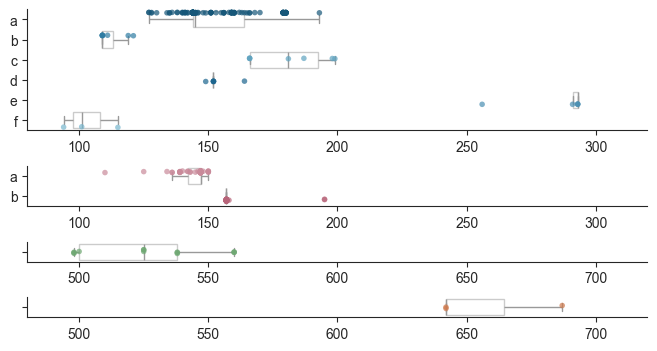

In [26]:
fig_data = all_act_overview[["length", "structure_cluster_rep"]]
class_dict = {"ncbi_uid_1971775846" : "class I", "ncbi_uid_1249580732": "class I", "ncbi_uid_1199937949": "class I",
              "ncbi_uid_1336447972": "class I", "ncbi_uid_604671243": "class I", "ncbi_uid_425702522": "class I",
              "ncbi_uid_114796469": "class II", "ncbi_uid_378407725": "class II", 
              "ncbi_uid_2296131990": "class III", "ncbi_uid_1682780652": "non-GNAT class"}
subclass_dict = {"ncbi_uid_1971775846" : "a", "ncbi_uid_1249580732": "b", "ncbi_uid_1199937949": "c",
              "ncbi_uid_1336447972": "d", "ncbi_uid_604671243": "e", "ncbi_uid_425702522": "f",
              "ncbi_uid_114796469": "a", "ncbi_uid_378407725": "b", 
              "ncbi_uid_2296131990": " ", "ncbi_uid_1682780652": " "}
fig_data["class"] = fig_data.apply(lambda row: class_dict.get(row["structure_cluster_rep"]), axis = 1)
fig_data["subclass"] = fig_data.apply(lambda row: subclass_dict.get(row["structure_cluster_rep"]), axis = 1)
sns.set_style("ticks", {"axes.grid" : False})
f, (ax_class1, ax_class2, ax_class3, ax_classng) = plt.subplots(4, gridspec_kw = {"height_ratios": (.6, .2, 0.1, 0.1)}, figsize = (8,4))
ax_class1.set_xlim(80, 320)
ax_class2.set_xlim(80, 320)
ax_class3.set_xlim(480, 720)
ax_classng.set_xlim(480, 720)
sns.boxplot(x = "length", y = "subclass", data = fig_data[fig_data["class"] == "class I"], color = "white", order = ["a", "b", "c", "d", "e", "f"],
            showcaps = True, boxprops = {"facecolor": "white", "alpha": 0.5}, whiskerprops = {"linewidth": 1}, fliersize = 0, ax = ax_class1)
sns.stripplot(x = "length", y = "subclass", data = fig_data[fig_data["class"] == "class I"], dodge = True, jitter = True, 
              size = 4, alpha = 0.7, palette = ["#175779", "#2f7ca3", "#5fa3c0", "#1d668f", "#4a8fb2", "#77b5cd"], 
              order = ["a", "b", "c", "d", "e", "f"], ax = ax_class1)
sns.boxplot(x = "length", y = "subclass", data = fig_data[fig_data["class"] == "class II"], color = "white", order = ["a", "b"],
            showcaps = True, boxprops = {"facecolor": "white", "alpha": 0.5}, whiskerprops = {"linewidth": 1}, fliersize = 0, ax = ax_class2)
sns.stripplot(x = "length", y = "subclass", data = fig_data[fig_data["class"] == "class II"], dodge = True, jitter = True, 
              size = 4, alpha = 0.7, palette = ["#c98a9a", "#b8657a"], ax = ax_class2)
sns.boxplot(x = "length", y = "subclass", data = fig_data[fig_data["class"] == "class III"], color = "white",
            showcaps = True, boxprops = {"facecolor": "white", "alpha": 0.5}, whiskerprops = {"linewidth": 1}, fliersize = 0, ax = ax_class3)
sns.stripplot(x = "length", y = "subclass", data = fig_data[fig_data["class"] == "class III"], dodge = True, jitter = True, 
              size = 4, alpha = 0.7, palette = ["#6FA873"], ax = ax_class3)
sns.boxplot(x = "length", y = "subclass", data = fig_data[fig_data["class"] == "non-GNAT class"], color = "white",
            showcaps = True, boxprops = {"facecolor": "white", "alpha": 0.5}, whiskerprops = {"linewidth": 1}, fliersize = 0, ax = ax_classng)
sns.stripplot(x = "length", y = "subclass", data = fig_data[fig_data["class"] == "non-GNAT class"], dodge = True, jitter = True, 
              size = 4, alpha = 0.7, palette = ["#CF7A4D"], ax = ax_classng)
# update which axes are shown to create clean overview
for ax in [ax_class1, ax_class2, ax_class3, ax_classng]:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set(xlabel="")
    ax.set(ylabel="")
    # to drop labels when writing to file - uncomment those
#    ax.set_xticklabels([])
#    ax.set_yticklabels([])
plt.subplots_adjust(hspace=0.7)
    # to save file - uncomment this
# f.savefig(os.path.join(pipeline_char_dir, "size_distibutions.svg"), format = "svg", transparent = True)

Let's now plot the presence (incl. count)/absence of the different classes of acetyltransferases in our phages, grouping our phages based on taxonomy: 

C:\Users\hanne\AppData\Local\Temp\ipykernel_25512\602515518.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fig_data["class"] = fig_data.apply(lambda row: class_dict.get(row["structure_cluster_rep"]), axis = 1)


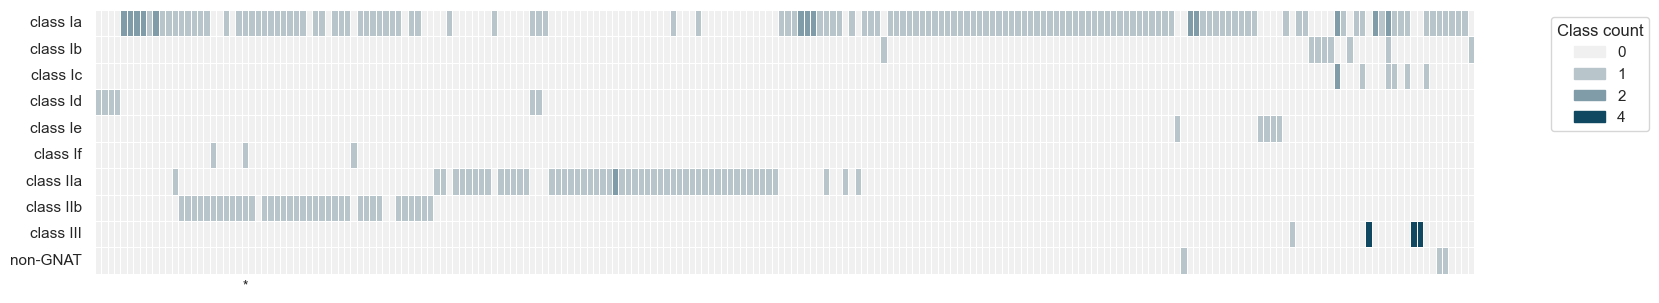

In [27]:
# subset of data relevant for figure
fig_data = all_act_overview[["virus_name", "virus_lineage", "structure_cluster_rep"]]
# add in class
class_dict = {"ncbi_uid_1971775846" : "class Ia", "ncbi_uid_1249580732": "class Ib", "ncbi_uid_1199937949": "class Ic",
              "ncbi_uid_1336447972": "class Id", "ncbi_uid_604671243": "class Ie", "ncbi_uid_425702522": "class If",
              "ncbi_uid_114796469": "class IIa", "ncbi_uid_378407725": "class IIb", 
              "ncbi_uid_2296131990": "class III", "ncbi_uid_1682780652": "non-GNAT"}
fig_data["class"] = fig_data.apply(lambda row: class_dict.get(row["structure_cluster_rep"]), axis = 1)
# create count table for heatmap
count_table = fig_data.groupby(["virus_name", "class"]).size().reset_index(name = "count")
heatmap_df = count_table.pivot(index = "class", columns = "virus_name", values = "count").fillna(0)
# sort the data based on virus taxonomy
name_to_lineage = fig_data.set_index("virus_name")["virus_lineage"].to_dict()
sorted_columns = sorted(heatmap_df.columns, key = lambda x: (name_to_lineage.get(x, ""), x))
heatmap_df = heatmap_df[sorted_columns]
# put the order of the classes back to their logical order
original_class_order = ["class Ia", "class Ib", "class Ic", "class Id", "class Ie", "class If", "class IIa", "class IIb", "class III", "non-GNAT"]
heatmap_df = heatmap_df.reindex(original_class_order)
# color code 
colors = ["#f0f0f0", "#b8c6cc", "#809ca9", "#487285", "#104862"]  
cmap = mcolors.ListedColormap(colors)
unique_values = sorted(set(heatmap_df.values.flatten().astype(int)))
patches = [mpatches.Patch(color = colors[val], label = str(val)) for val in unique_values]
# actually plot
sns.set_theme(style = "white")
plt.figure(figsize = (15, 3))
sns.heatmap(heatmap_df, cmap = cmap, vmin = 0, vmax = 4, cbar = False, linewidths = 0.6)
plt.xticks([], []) 
plt.ylabel("")
plt.xlabel("")
plt.tight_layout()
# add label to indicate MPK6 with 'duplicate'
if "Pseudomonas phage MPK6" in heatmap_df.columns:
    idx = heatmap_df.columns.get_loc("Pseudomonas phage MPK6")  # Get column index
    plt.text(x = idx + 0.5, y = heatmap_df.shape[0] + 0.2, s = "*", ha = "center", va = "top", fontsize=10)
# to drop legend when writing file - comment this out
plt.legend(handles = patches, title = "Class count", bbox_to_anchor = (1.05, 1), loc = "upper left")
# to drop labels when writing to file - uncomment those
# plt.yticks([], []) 
# to write file - uncomment this
# plt.savefig(os.path.join(pipeline_char_dir, "heatmap_class_phage.svg"), format = "svg", transparent = True)

Let's also create a variant that clearly shows the distinction between different genera:

In [28]:
# function to extract lineage up to genus level
def extract_until_genus(text):
    index = text.find("virus")
    if index != -1:
        return text[:(index + 5)].strip()
    else:
        return text

C:\Users\hanne\AppData\Local\Temp\ipykernel_25512\3807106270.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fig_data["class"] = fig_data.apply(lambda row: class_dict.get(row["structure_cluster_rep"]), axis = 1)
C:\Users\hanne\AppData\Local\Temp\ipykernel_25512\3807106270.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fig_data["genus"] = fig_data["virus_lineage"].apply(lambda x: extract_until_genus(x))


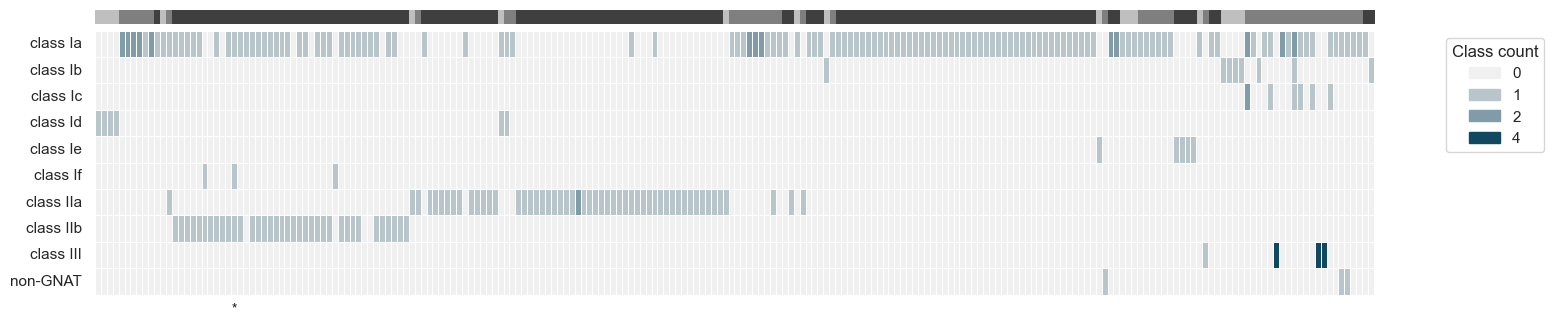

In [30]:
# subset of data relevant for figure
fig_data = all_act_overview[["virus_name", "virus_lineage", "structure_cluster_rep"]]
# add in class
class_dict = {"ncbi_uid_1971775846" : "class Ia", "ncbi_uid_1249580732": "class Ib", "ncbi_uid_1199937949": "class Ic",
              "ncbi_uid_1336447972": "class Id", "ncbi_uid_604671243": "class Ie", "ncbi_uid_425702522": "class If",
              "ncbi_uid_114796469": "class IIa", "ncbi_uid_378407725": "class IIb", 
              "ncbi_uid_2296131990": "class III", "ncbi_uid_1682780652": "non-GNAT"}
fig_data["class"] = fig_data.apply(lambda row: class_dict.get(row["structure_cluster_rep"]), axis = 1)
# create count table for heatmap
count_table = fig_data.groupby(["virus_name", "class"]).size().reset_index(name = "count")
heatmap_df = count_table.pivot(index = "class", columns = "virus_name", values = "count").fillna(0)
# sort the data based on virus taxonomy
name_to_lineage = fig_data.set_index("virus_name")["virus_lineage"].to_dict()
sorted_columns = sorted(heatmap_df.columns, key = lambda x: (name_to_lineage.get(x, ""), x))
heatmap_df = heatmap_df[sorted_columns]
# put the order of the classes back to their logical order
original_class_order = ["class Ia", "class Ib", "class Ic", "class Id", "class Ie", "class If", "class IIa", "class IIb", "class III", "non-GNAT"]
heatmap_df = heatmap_df.reindex(original_class_order)
# color code for heatmap (counts)
colors = ["#f0f0f0", "#b8c6cc", "#809ca9", "#487285", "#104862"]  
cmap = mcolors.ListedColormap(colors)
unique_values = sorted(set(heatmap_df.values.flatten().astype(int)))
patches = [mpatches.Patch(color = colors[val], label = str(val)) for val in unique_values]
# add in color for genus bar
    # extract the genus
fig_data["genus"] = fig_data["virus_lineage"].apply(lambda x: extract_until_genus(x))
genus_for_columns = [fig_data.loc[fig_data["virus_name"] == col, "genus"].iloc[0] for col in sorted_columns]
unique_genus = sorted(set(genus_for_columns))
    # assign the colors, as a repetition of 3
base_colors = sns.color_palette("binary", n_colors = 3)
color_indices = [i % len(base_colors) for i in range(len(unique_genus))]
genus_color_map = dict(zip(unique_genus, [base_colors[i] for i in color_indices]))
genus_color_row = [genus_color_map[g] for g in genus_for_columns]
# actually plot
sns.set_theme(style = "white")
plt.figure(figsize = (14, 3))
ax = sns.heatmap(heatmap_df, cmap = cmap, vmin = 0, vmax = 4, cbar = False, linewidths = 0.6)
ax.set_xticks([], []) 
ax.set_ylabel("")
ax.set_xlabel("")
ax.figure.tight_layout()
# add genus color bar
top_ax = ax.figure.add_axes([ax.get_position().x0, ax.get_position().y1 + 0.02, ax.get_position().width, 0.05])
top_ax.imshow([genus_color_row], aspect ="auto")
top_ax.set_xticks([])
top_ax.set_yticks([])
top_ax.set_frame_on(False)
# add label to indicate MPK6 with 'duplicate'
if "Pseudomonas phage MPK6" in heatmap_df.columns:
    idx = heatmap_df.columns.get_loc("Pseudomonas phage MPK6")  # Get column index
    plt.text(x = idx + 0.1, y = heatmap_df.shape[0] + 9, s = "*", ha = "center", va = "top", fontsize=10)
# to drop legend when writing file - comment this out
ax.legend(handles = patches, title = "Class count", bbox_to_anchor = (1.05, 1), loc = "upper left")
# to drop labels when writing to file - uncomment those
# ax.set_yticks([], []) 
# to write file - uncomment this
# ax.figure.savefig(os.path.join(pipeline_char_dir, "heatmap_class_phage_genus.svg"), format = "svg", transparent = True)